# IMPORTS

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                     BatchNormalization, Bidirectional)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)


2026-05-09 19:07:06.786040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778353627.205627      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778353627.325503      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778353628.266557      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778353628.266604      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778353628.266608      57 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Chargement et exploration des données 
On inspecte la **forme**, les **types de colonnes**, un **aperçu** et les **statistiques descriptives** pour chaque fichier.

| Colonne | Description |
|---|---|
| `Timestamp` | Heure de capture du message |
| `CAN_ID` | Identifiant du composant émetteur (en hex) |
| `DLC` | Nombre d'octets de données (0 à 8) |
| `D0` à `D7` | Les 8 octets de données (en hex) |
| `Flag` | Label : **R** = Normal, **T** = Attaque |

Chargement terminé
  Normal  →    988,872 lignes
  DoS     →  3,665,771 lignes
  Fuzzy   →  3,838,860 lignes
  Gear    →  4,443,142 lignes
  RPM     →  4,621,702 lignes

  Normal Dataset
Shape        : (988872, 12)
Types        :
Timestamp     object
CAN_ID       float64
DLC          float64
D0           float64
D1           float64
D2           float64
D3           float64
D4           float64
D5           float64
D6           float64
D7           float64
Flag         float64
dtype: object
Aperçu       :
                                           Timestamp  CAN_ID  DLC  D0  D1  D2  \
0  Timestamp: 1479121434.850202        ID: 0350  ...     NaN  NaN NaN NaN NaN   
1  Timestamp: 1479121434.850423        ID: 02c0  ...     NaN  NaN NaN NaN NaN   
2  Timestamp: 1479121434.850977        ID: 0430  ...     NaN  NaN NaN NaN NaN   
3  Timestamp: 1479121434.851215        ID: 04b1  ...     NaN  NaN NaN NaN NaN   
4  Timestamp: 1479121434.851463        ID: 01f1  ...     NaN  NaN NaN NaN NaN   

  

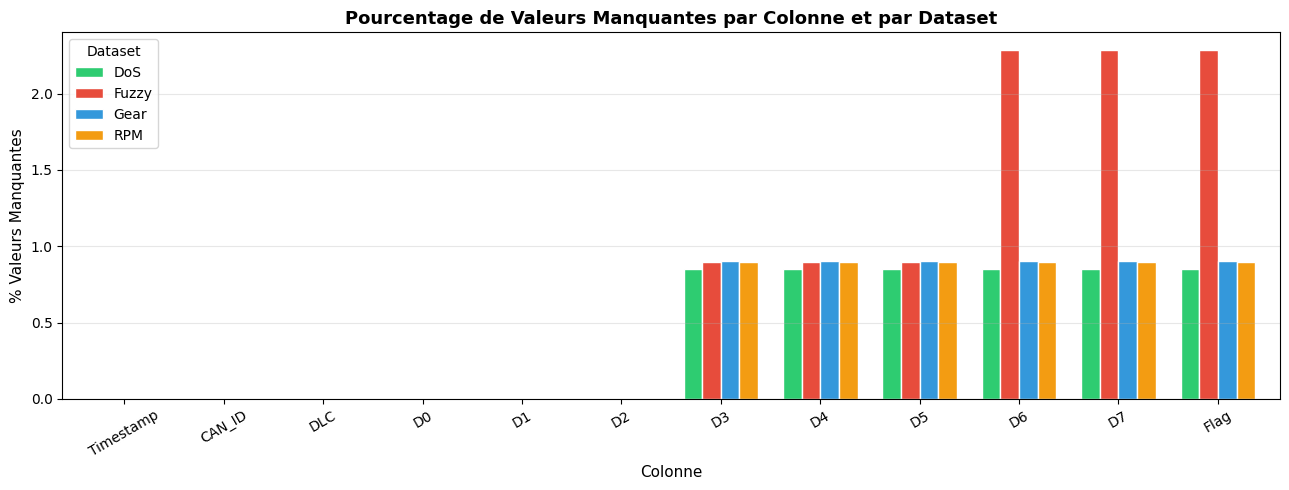

 Données chargées avec succès


In [2]:

COLS = ['Timestamp', 'CAN_ID', 'DLC',
        'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

BASE = '/kaggle/input/datasets/pranavjha24/car-hacking-dataset/'

normal = pd.read_csv(BASE + 'normal_run_data.txt',   header=None, names=COLS)
dos    = pd.read_csv(BASE + 'DoS_dataset.csv',       header=None, names=COLS)
fuzzy  = pd.read_csv(BASE + 'Fuzzy_dataset.csv',     header=None, names=COLS)
gear   = pd.read_csv(BASE + 'gear_dataset.csv',      header=None, names=COLS)
rpm    = pd.read_csv(BASE + 'RPM_dataset.csv',       header=None, names=COLS)

print("Chargement terminé")
for name, d in [('Normal', normal), ('DoS', dos),
                ('Fuzzy', fuzzy),   ('Gear', gear), ('RPM', rpm)]:
    print(f"  {name:7s} → {len(d):>10,} lignes")

datasets = {
    "Normal": normal,
    "DoS"   : dos,
    "Fuzzy" : fuzzy,
    "Gear"   : gear,
    "RPM"  : rpm,
}
dataset = {
    "DoS"   : dos,
    "Fuzzy" : fuzzy,
    "Gear"   : gear,
    "RPM"  : rpm,
}

for name, df in datasets.items():
    print(f"\n{'='*45}")
    print(f"  {name} Dataset")
    print(f"{'='*45}")
    print(f"Shape        : {df.shape}")
    print(f"Types        :\n{df.dtypes}")
    print(f"Aperçu       :\n{df.head()}")
    print(f"Statistiques :\n{df.describe()}")


import matplotlib.pyplot as plt
import missingno as msno


missing = pd.DataFrame({
    name: (df.isnull().sum() / len(df) * 100)
    for name, df in dataset.items()
})

# Graphe
fig, ax = plt.subplots(figsize=(13, 5))

missing.plot(kind='bar', ax=ax,
             color=['#2ECC71', '#E74C3C', '#3498DB', '#F39C12', '#9B59B6'],
             edgecolor='white', width=0.75)

ax.set_title('Pourcentage de Valeurs Manquantes par Colonne et par Dataset',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Colonne', fontsize=11)
ax.set_ylabel('% Valeurs Manquantes', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Dataset', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('valeurs_manquantes.png', dpi=150)
plt.show()

print(" Données chargées avec succès")


# Ajout de la variable target attack_type
On prépare la variable cible pour une classification multi-classe des attaques CAN bus. Initialement la variable flag prenait 2 valeur R (random), T (Tempted).
On crée un colonne attack_type qui sera notre nouvelle colonne target et on attribue un code numérique à chaque type d’attaque (DoS = 1, Fuzzy=1, Gear=3, RPM=4 SI la variable Flag prend T comme valeur ) tandis que le trafic normal reçoit le label 0. Ensuite on supprime la colonne flag

In [3]:

def assign_attack_type(df, attack_code):
    d = df.copy()
    d['Flag'] = d['Flag'].astype(str).str.strip().str.upper()
    d = d[d['Flag'].isin(['R', 'T'])].copy()
    if attack_code == 0:
        d['attack_type'] = 0
    else:
        d['attack_type'] = d['Flag'].map({'R': 0, 'T': attack_code})
    return d

normal_c = assign_attack_type(normal, 0)
dos_c    = assign_attack_type(dos,    1)
fuzzy_c  = assign_attack_type(fuzzy,  2)
gear_c   = assign_attack_type(gear,   3)
rpm_c    = assign_attack_type(rpm,    4)

labels_map = {0: 'Normal', 1: 'DoS', 2: 'Fuzzy', 3: 'Gear', 4: 'RPM'}

# Pré-traitement des données via la fonction preprocess
1. Conversion des données Hexadécimales
   * Conversion des colonnes CAN et des données D0, D1, ... D7 en decimal via la fonction parse.hex()
   * Nettoyage : On supprime les préfixes "ID:", "0X", les espaces et gère les valeurs manquantes (NaN).
3. Traitement du protocole CAN en calculant le Delta_T via la colonne Timestamp qui est une donnée cruciale pour détecter des attaques de type "DoS" (inondation de messages) où le débit change brutalement.
4. Gestion des valeurs manquantes et suppression
    * Suppression sélective : Si une ligne est marquée comme "normale" (attack_type == 0) mais qu'elle contient des données manquantes (NaN) dans les colonnes importantes, elle est supprimée.
    * Remplissage (Imputation) : Pour les autres cas, les valeurs manquantes sont remplacées par 0.
    *  Suppression de colonnes : On supprime les colonnes Timestamp (une fois le Delta calculé) et Flag qui ne sont plus nécessaires pour l'analyse

In [4]:

def preprocess(df):
    d = df.copy()

    # Fonction qui convertit du hexa vers le decimal 
    def parse_hex(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().upper()
        s = s.replace('ID:', '').replace('0X', '').replace(' ', '')
        if s == '' or s == 'NAN':
            return np.nan
        try:
            return int(s, 16)
        except ValueError:
            return np.nan

    # 1. Conversion des colonnes de données et de l'ID du message
    HEX_COLS = ['CAN_ID', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']
    for col in HEX_COLS:
        d[col] = d[col].apply(parse_hex)

    # 2. Conversion du DLC (Data Length Code) en numérique
    d['DLC'] = pd.to_numeric(d['DLC'], errors='coerce')

    # 3. Traitement du Timestamp
    d['Timestamp'] = (d['Timestamp']
                      .astype(str)
                      .str.extract(r'([\d\.]+)', expand=False))
    d['Timestamp'] = pd.to_numeric(d['Timestamp'], errors='coerce')
    d['Delta_T']   = d['Timestamp'].diff().fillna(0)
    d = d.drop(columns=['Timestamp', 'Flag'])

    # 4. Gestion des valeurs manquantes (NaN)
    FEAT_COLS = ['CAN_ID', 'DLC', 'D0', 'D1', 'D2',
                 'D3', 'D4', 'D5', 'D6', 'D7', 'Delta_T']
    # On identifie les lignes "Normales" (attack_type == 0) qui ont des vides
    # et on les supprime 
    masque_normal_nan = (d['attack_type'] == 0) & d[FEAT_COLS].isnull().any(axis=1)
    d = d[~masque_normal_nan]
    #Remplir les valeurs manquantes par des 0
    d[FEAT_COLS] = d[FEAT_COLS].fillna(0)

    return d

print("Pré-traitement en cours...")
normal_p = preprocess(normal_c)
dos_p    = preprocess(dos_c)
fuzzy_p  = preprocess(fuzzy_c)
gear_p   = preprocess(gear_c)
rpm_p    = preprocess(rpm_c)
print("Pré-traitement terminé")

Pré-traitement en cours...
Pré-traitement terminé


# Fusion et équilibrage du dataset
* Fusion & Visualisation : On regroupe toutes les données et on affiche la répartition initiale via un premier graphique.

* Équilibrage (Resampling) : on force chaque classe à atteindre exactement 400 000 lignes en réduisant les classes trop grandes ou en dupliquant les classes trop petites.

* Mélange : on mixe aléatoirement le tout + affichage du graphique.

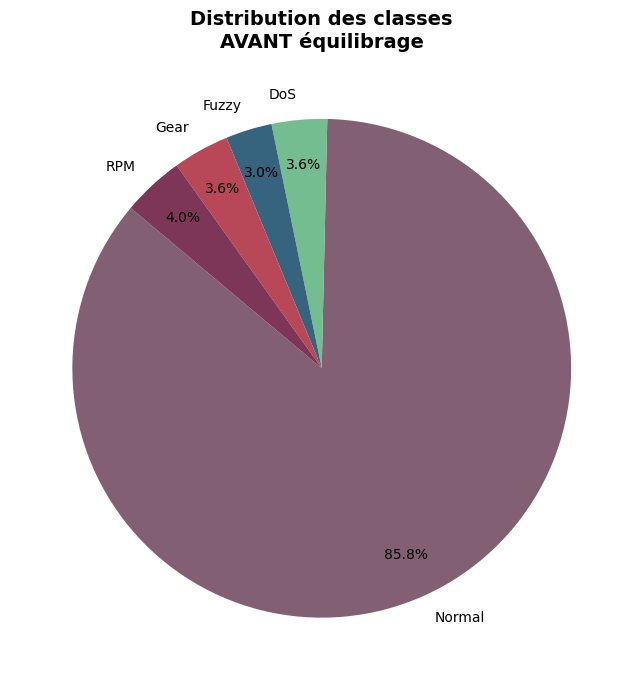

  Normal  : 14,037,293 reduit à 400,000 (sous-échantillonné)
  DoS     :    587,521 reduit à 400,000 (sous-échantillonné)
  Fuzzy   :    491,847 reduit à 400,000 (sous-échantillonné)
  Gear    :    597,252 reduit à 400,000 (sous-échantillonné)
  RPM     :    654,897 reduit à 400,000 (sous-échantillonné)

Dataset équilibré : 2,000,000 lignes


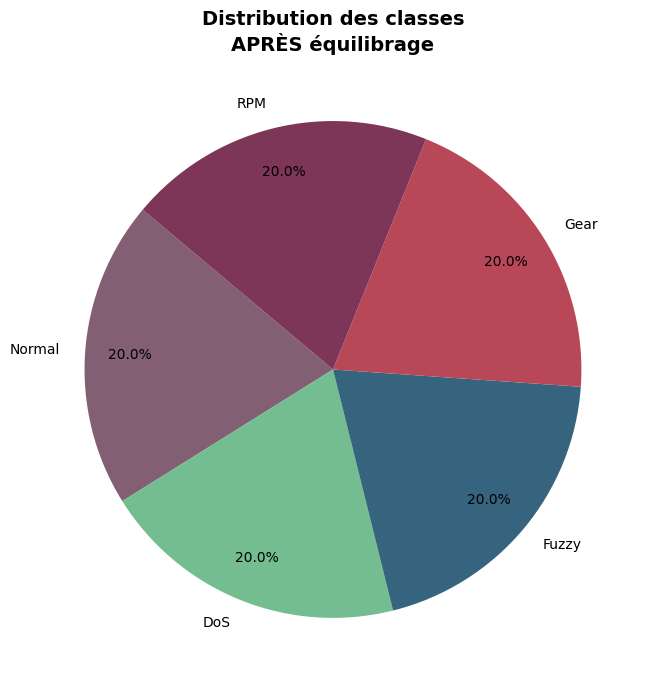

In [12]:

data_raw = pd.concat([normal_p, dos_p, fuzzy_p, gear_p, rpm_p],
                     ignore_index=True)

colors      = ['#825F72', '#73BD90', '#36637D', '#B84758', '#7D3657']
N_PAR_CLASSE = 400_000

# Diagramme avant
counts_before = data_raw['attack_type'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts_before.values,
       labels=[labels_map[i] for i in counts_before.index],
       colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.82)
ax.set_title('Distribution des classes\nAVANT équilibrage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_avant.png', dpi=150)
plt.show()

# Équilibrage
frames = []
for code, name in labels_map.items():
    subset = data_raw[data_raw['attack_type'] == code]
    n_dispo = len(subset)
    if n_dispo == 0:
        print(f"   {name} : 0 lignes — ignorée")
        continue
    if n_dispo >= N_PAR_CLASSE:
        subset = subset.sample(n=N_PAR_CLASSE, random_state=42)
        print(f"  {name:7s} : {n_dispo:>10,} reduit à {N_PAR_CLASSE:,} (sous-échantillonné)")
    else:
        subset = subset.sample(n=N_PAR_CLASSE, replace=True, random_state=42)
        print(f"  {name:7s} : {n_dispo:>10,} augmente à {N_PAR_CLASSE:,} (sur-échantillonné)")
    frames.append(subset)

data_bal = pd.concat(frames, ignore_index=True)
data_bal = data_bal.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nDataset équilibré : {len(data_bal):,} lignes")

# Diagramme apres
counts_after = data_bal['attack_type'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(counts_after.values,
       labels=[labels_map[i] for i in counts_after.index],
       colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.82)
ax.set_title('Distribution des classes\nAPRÈS équilibrage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_apres.png', dpi=150)
plt.show()

# Split 80/20 + Normalisation 

* Séparation (Split) : On divise les données en utilisant 80% pour l'entraînement et 20% pour le test, avec l'option stratify qui garantit que chaque type d'attaque est représenté de manière égale dans les deux groupes.

* Normalisation (Scaling) : Via MinMaxScaler, on convertit toutes les valeurs (ID, octets de données, temps) pour qu'elles tiennent entre 0 et 1.

 Cela permet d'uniformiser les échelles de données, et permet au modèle d'apprendre plus efficacement.

In [19]:

FEATURES = ['CAN_ID', 'DLC', 'D0', 'D1', 'D2',
            'D3', 'D4', 'D5', 'D6', 'D7', 'Delta_T']

X = data_bal[FEATURES].values
y = data_bal['attack_type'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")

X_train : (1600000, 11) | X_test : (400000, 11)


# Reshape pour LSTM
* Séquençage (make_sequences) : On transforme les données plates en fenêtres glissantes de 10 trames consécutives. Le modèle ne regarde plus un seul message CAN, mais l'historique des 10 derniers pour mieux repérer les anomalies temporelles

* Formatage 3D : Il change la structure des données en (échantillons, 10 pas de temps, 11 caractéristiques), le format standard pour que le LSTM puisse traiter les séquences.

* One-Hot Encoding : Il convertit les étiquettes de classes (0, 1, 2...) en vecteurs binaires, format indispensable pour la couche de sortie du réseau de neurones.




In [20]:


TIMESTEPS = 10               # fenêtre temporelle : 10 trames CAN
N_FEATURES = len(FEATURES)   # 11 features par trame
N_CLASSES  = 5               # nombre de classes (sortie) 

def make_sequences(X, y, timesteps):
    
    n_samples = len(X) - timesteps + 1
    X_seq = np.array([X[i: i + timesteps] for i in range(n_samples)])
    y_seq = y[timesteps - 1:]      # label = dernière trame de la fenêtre
    return X_seq, y_seq


X_train_seq, y_train_seq = make_sequences(X_train, y_train, TIMESTEPS)
X_test_seq,  y_test_seq  = make_sequences(X_test,  y_test,  TIMESTEPS)

#print(f"  X_train_seq : {X_train_seq.shape}")   
#print(f"  X_test_seq  : {X_test_seq.shape}")
#print(f"  y_train_seq : {y_train_seq.shape}")
#print(f"  y_test_seq  : {y_test_seq.shape}")

# One-hot encoding
y_train_oh = to_categorical(y_train_seq, num_classes=N_CLASSES)
y_test_oh  = to_categorical(y_test_seq,  num_classes=N_CLASSES)

# Architecture de système LSTM
1. Les couches de mémoire (LSTM)
   
* Bidirectional LSTM (128 unités) : une 1ere couche qui lit la séquence de 10 messages dans les deux sens. Cela permet au modèle de comprendre le contexte complet d'un message suspect par rapport à ce qui arrive avant et après lui.

* LSTM (64 unités) : Une deuxième couche qui affine l'analyse des motifs détectés par la première.

2. Dropout et batchnormalization
   
* 3 Dropout  : désactive aléatoirement certains neurones. Cela force le modèle à ne pas devenir trop dépendant de détails précis et à mieux généraliser (évite l'overfitting).

* BatchNormalization : pour recalibrer les données entre les couches pour que l'apprentissage reste stable et rapide, évitant que les calculs ne s'emballent.

3. La prise de décision
   
* Dense (64, 'relu') : Une couche classique qui interprète les patterns extraits par les LSTM.

* Dense (Sortie, 'softmax') : La couche finale qui transforme les calculs en probabilités. Elle sort 5 chiffres (un par classe) dont la somme vaut 100%. La classe avec la probabilité la plus élevée sera la prédiction du modèle.

4. Ajustement des poids et Loss function et metriques
   
* Adaptive Moment Estimation optimizer (Adam)

* Categorical Crossentropy : calcule le taux d'erreur

* Accuracy pour évaluer la qualité des predictions

In [21]:

def build_lstm(timesteps, n_features, n_classes):
    model = Sequential([

        # Couche 1 : Bidirectional LSTM
        Bidirectional(
            LSTM(128, return_sequences=True),
            input_shape=(timesteps, n_features)
        ),
        Dropout(0.3),

        # Couche 2 : LSTM simple
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),

        # Tête de classification
        Dense(64, activation='relu'),
        Dropout(0.2),

        # Sortie
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm(TIMESTEPS, N_FEATURES, N_CLASSES)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 10, 256)        │       143,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,277 (899.52 KB)

 Trainable params: 230,149 (899.02 KB)

 Non-trainable params: 128 (512.00 B)

# Entrainement
1. Callbacks
* EarlyStopping (Arrêt précoce) : Si le modèle arrête de s'améliorer (pendant 5 époques), l'entraînement s'arrête automatiquement. Cela évite de perdre du temps et empêche le modèle de commencer à faire du overfitting et recharge aussi les meilleurs poids trouvés avant de s'arrêter.

* ReduceLROnPlateau : Si la progression stagne on réduit de moitié la vitesse d'apprentissage (factor=0.5).

2. Configuration du Fit
* batch_size=512 : Le modèle regarde 512 séquences à la fois avant de mettre à jour ses connaissances. C'est un compromis pour ne pas saturer la RAM tout en allant vite.

* validation_split=0.15 : On garde 15% des données d'entraînement pour s'auto-évaluer à chaque étape et vérifier qu'il apprend correctement.

* epochs=50 : nombre maximum de passages complets sur les données 



In [22]:


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train_seq, y_train_oh,
    epochs=50,
    batch_size=512,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print("\nEntraînement terminé")
print(f"  Epochs effectués   : {len(history.history['loss'])}")
print(f"  Meilleure val_loss : {min(history.history['val_loss']):.4f}")
print(f"  Meilleure val_acc  : {max(history.history['val_accuracy']):.4f}")

Epoch 1/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.9476 - loss: 0.1429 - val_accuracy: 0.9978 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 2/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.9973 - loss: 0.0099 - val_accuracy: 0.9991 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9988 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 4/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 5/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9997 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9998 - val_loss: 9.5738e-04 - learning_rate: 0.0010
Epoch 7/50
2657/2657 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - ac

# Courbes Loss et Accuracy
Visualiser le taux d'erreur et l'accuracy du modèle

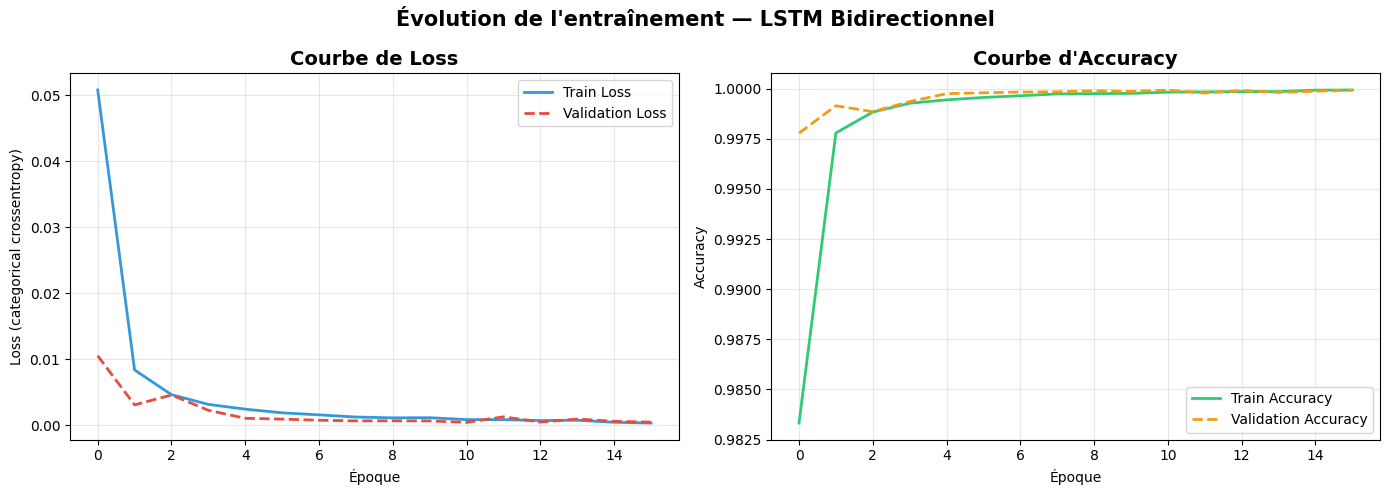

Courbes Loss et Accuracy


In [23]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',
             color='#3498DB', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss',
             color='#E74C3C', linewidth=2, linestyle='--')
axes[0].set_title('Courbe de Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss (categorical crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy',
             color='#2ECC71', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy',
             color='#F39C12', linewidth=2, linestyle='--')
axes[1].set_title("Courbe d'Accuracy", fontsize=14, fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Évolution de l'entraînement — LSTM Bidirectionnel",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('Courbes Loss et Accuracy', dpi=150)
plt.show()
print("Courbes Loss et Accuracy")

# Evaluation sur le jeu de test
* Prédiction : On analyse les données de test et choisit pour chaque séquence la classe ayant la plus haute probabilité (via np.argmax).

* Scores globaux : On calcule l'Accuracy (précision globale) et le F1-Score (équilibre entre détection réussie et fausses alertes) pour juger l'efficacité du système.


In [24]:


y_pred_prob = model.predict(X_test_seq, batch_size=512, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

acc    = accuracy_score(y_test_seq, y_pred)
f1_mac = f1_score(y_test_seq, y_pred, average='macro')
f1_wei = f1_score(y_test_seq, y_pred, average='weighted')

print("=" * 55)
print("   RÉSULTATS SUR LE JEU DE TEST — LSTM")
print("=" * 55)
print(f"  Accuracy globale  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1-Score macro    : {f1_mac:.4f}")
print(f"  F1-Score weighted : {f1_wei:.4f}")
print("=" * 55)

target_names = [labels_map[i] for i in range(N_CLASSES)]
print("\nRapport de classification par classe :")
print(classification_report(y_test_seq, y_pred, target_names=target_names))

   RÉSULTATS SUR LE JEU DE TEST — LSTM
  Accuracy globale  : 0.9999  (99.99%)
  F1-Score macro    : 0.9999
  F1-Score weighted : 0.9999

Rapport de classification par classe :
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     79994
         DoS       1.00      1.00      1.00     80000
       Fuzzy       1.00      1.00      1.00     79998
        Gear       1.00      1.00      1.00     79999
         RPM       1.00      1.00      1.00     80000

    accuracy                           1.00    399991
   macro avg       1.00      1.00      1.00    399991
weighted avg       1.00      1.00      1.00    399991



# Matrice de confusion

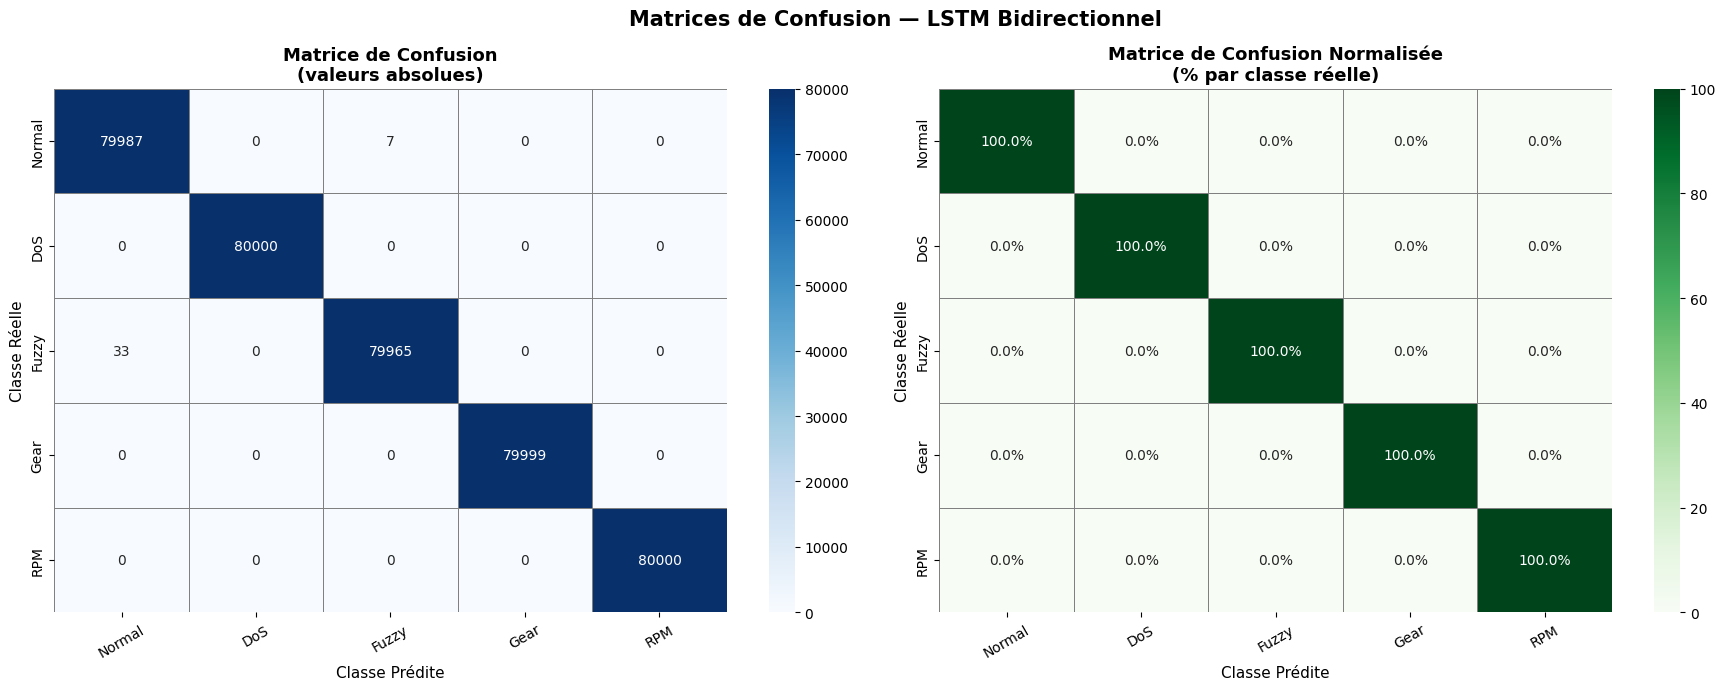

Graphe sauvegardé : matrice_confusion_lstm.png


In [25]:

cm      = confusion_matrix(y_test_seq, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Matrice brute ────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[0], linewidths=0.5, linecolor='gray')
axes[0].set_title('Matrice de Confusion\n(valeurs absolues)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe Prédite',  fontsize=11)
axes[0].set_ylabel('Classe Réelle',   fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# ── Matrice normalisée ───────────────────────────────────────
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            vmin=0, vmax=100)
axes[1].set_title('Matrice de Confusion Normalisée\n(% par classe réelle)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe Prédite',  fontsize=11)
axes[1].set_ylabel('Classe Réelle',   fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

for text in axes[1].texts:
    text.set_text(text.get_text() + '%')

plt.suptitle('Matrices de Confusion — LSTM Bidirectionnel',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('matrice_confusion_lstm', dpi=150)
plt.show()
print("matrice_confusion_lstm")

# Recapitulatif 

In [26]:


print("\n" + "=" * 55)
print("   RÉCAPITULATIF DU PROJET — LSTM")
print("=" * 55)
print(f"  Dataset total (équilibré) : {len(data_bal):,} lignes")
print(f"  Lignes par classe         : {N_PAR_CLASSE:,}")
print(f"  Features utilisées        : {len(FEATURES)}")
print(f"  Timesteps (fenêtre)       : {TIMESTEPS} trames CAN")
print(f"  Train / Test              : 80% / 20% (stratifié)")
print(f"  Architecture              : BiLSTM(128) → LSTM(64) → Dense(64) → 5")
print(f"  Epochs effectués          : {len(history.history['loss'])}")
print("─" * 55)
print(f"  Accuracy test             : {acc*100:.2f}%")
print(f"  F1-Score macro            : {f1_mac:.4f}")
print(f"  F1-Score weighted         : {f1_wei:.4f}")
print("=" * 55)

print("\nAccuracy par classe :")
for i, name in labels_map.items():
    mask  = (y_test_seq == i)
    if mask.sum() == 0:
        continue
    acc_i = accuracy_score(y_test_seq[mask], y_pred[mask])
    print(f"  Classe {i} ({name:12s}) : {acc_i*100:.2f}%")


   RÉCAPITULATIF DU PROJET — LSTM
  Dataset total (équilibré) : 2,000,000 lignes
  Lignes par classe         : 400,000
  Features utilisées        : 11
  Timesteps (fenêtre)       : 10 trames CAN
  Train / Test              : 80% / 20% (stratifié)
  Architecture              : BiLSTM(128) → LSTM(64) → Dense(64) → 5
  Epochs effectués          : 16
───────────────────────────────────────────────────────
  Accuracy test             : 99.99%
  F1-Score macro            : 0.9999
  F1-Score weighted         : 0.9999

Accuracy par classe :
  Classe 0 (Normal      ) : 99.99%
  Classe 1 (DoS         ) : 100.00%
  Classe 2 (Fuzzy       ) : 99.96%
  Classe 3 (Gear        ) : 100.00%
  Classe 4 (RPM         ) : 100.00%
